# Experiment examples — one axis at a time

What a BlueSkyCDaRR experiment looks like for each study variable:
**crossing angle (dpsi)**, **position uncertainty (pos_ci95)**, **velocity
uncertainty (vel_ci95)**, **reception probability**, **surveillance range**,
and the categorical **aircraft type**. One section per experiment; each is a
single `run_experiment` call with a `Sweep` on that axis, everything else held
at a common baseline.

Two things to know while reading the plots:

- **Common random numbers** (ADR 0004): every condition replays the same
  encounters and noise draws, so differences along an axis are physics, not
  sampling — that is why single-axis responses come out smooth.
- **The baseline is deliberately stressed** — pos_ci95 30 m, vel_ci95 3 m/s,
  reception 0.8, range 3000 m — so every axis has visible signal at a small
  budget (200 encounters/condition, ~1–2 min total). The study file
  `configs/mixedvarlse.yaml` holds its own defaults and 300+ encounters.

Uncertainty is reported as raw counts only (`n_los`, `n_encounters` in the
tables) — no interval columns, by decision (ADR 0004 update).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cdarr import (
    MC, CommConfig, Config, Models, MULTIROTOR, PairwiseEncounter, Sweep,
    UncertaintyConfig, run_experiment,
)

BASE = Config(
    uncertainty=UncertaintyConfig(pos_ci95=30.0, vel_ci95=3.0),
    comm=CommConfig(
        reception_prob=0.8, max_range_m=3000.0, latency_s=0.1,
        broadcast_interval_s=1.0, broadcast_jitter_s=0.1,
    ),
)
MODELS = Models(aircraft=MULTIROTOR, scenario=PairwiseEncounter())  # dpsi 90, dcpa 0
BACKEND = MC(n_encounters=200)
SEED, N_JOBS = 7, 4


def run(axes):
    return run_experiment(axes, models=MODELS, backend=BACKEND, base_config=BASE,
                          seed=SEED, n_jobs=N_JOBS, progress=False)


def plot_response(df, x, xlabel, log_x=False, title=''):
    fig, ax = plt.subplots(figsize=(6.8, 3.8))
    ax.plot(df[x], df['p_los_run'], '-o', ms=4, lw=1.3)
    if log_x:
        ax.set_xscale('log')
        ax.set_xticks(df[x], [f'{v:g}' for v in df[x]])
        ax.minorticks_off()
    ax.set_xlabel(xlabel)
    ax.set_ylabel('P(LoS) per encounter')
    ax.set_title(title, fontsize=10)
    plt.show()

## 1. Crossing angle — `dpsi`

A geometry slot: the intruder's track relative to the ownship's, pinned per
condition here (a `null`/`None` slot would draw it per pair instead). Shallow
crossings are the hard ones — the geometry stays convergent for a long time,
detection comes late relative to closure, and the past-CPA release has the
least margin — so expect P(LoS) to fall as the crossing opens up.

,dpsi,n_encounters,n_los,p_los_run,detection_rate,median_min_sep,n_unsettled
0,15.0,200,3,0.015,1.0,85.2994,0
1,45.0,200,0,0.000,1.0,107.5118,0
2,90.0,200,0,0.000,1.0,113.9731,0
3,135.0,200,0,0.000,1.0,116.3351,0
4,180.0,200,2,0.010,1.0,112.7345,0


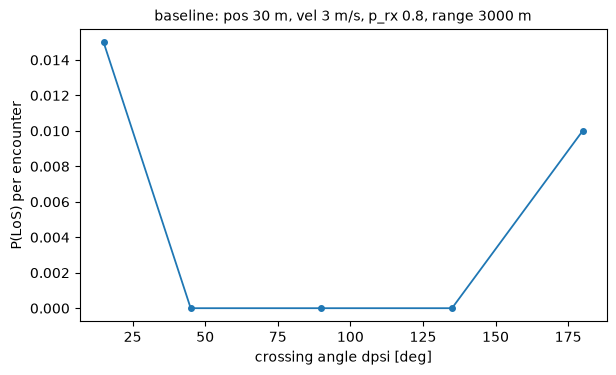

raw estimate @ dpsi=90: 0/200 losses, median min-sep 114.0 m


In [2]:
res_dpsi = run({'dpsi': Sweep([15.0, 45.0, 90.0, 135.0, 180.0])})
df = res_dpsi.to_dataframe()
display(df.round(4))
plot_response(df, 'dpsi', 'crossing angle dpsi [deg]',
              title='baseline: pos 30 m, vel 3 m/s, p_rx 0.8, range 3000 m')

cell = res_dpsi.cell(dpsi=90.0)   # the raw estimate behind one condition
print(f'raw estimate @ dpsi=90: {cell.n_los}/{cell.n_encounters} losses, '
      f'median min-sep {cell.median_min_sep:.1f} m')

## 2. Position uncertainty — `pos_ci95`

The ADS-L accuracy classes of the study (3 / 10 / 30 / 92.6 m, 95% radial CI).
It corrupts both what each aircraft believes about itself (navigation) and
what its broadcasts carry (ADR 0002). The chain absorbs a lot of position
noise before breaking — the interesting move happens at the last level.

,pos_ci95,n_encounters,n_los,p_los_run,detection_rate,median_min_sep,n_unsettled
0,3.0,200,0,0.000,1.0,109.9274,0
1,10.0,200,1,0.005,1.0,110.9318,0
2,30.0,200,0,0.000,1.0,113.9731,0
3,92.6,200,9,0.045,1.0,140.8432,0


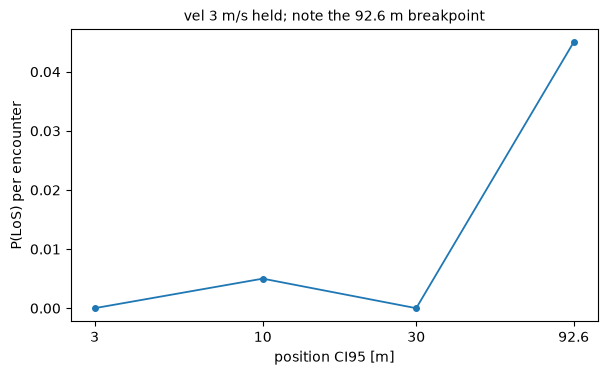

In [3]:
res_pos = run({'pos_ci95': Sweep([3.0, 10.0, 30.0, 92.6])})
df = res_pos.to_dataframe()
display(df.round(4))
plot_response(df, 'pos_ci95', 'position CI95 [m]', log_x=True,
              title='vel 3 m/s held; note the 92.6 m breakpoint')

## 3. Velocity uncertainty — `vel_ci95`

The axis the resolver feels most: MVP steers on a CPA *prediction*, and the
prediction is linear in the relative velocity — so velocity noise moves the
predicted miss directly. The study's ordinal levels are 1 and 3 m/s; the wider
sweep here shows the shape they sit on.

,vel_ci95,n_encounters,n_los,p_los_run,detection_rate,median_min_sep,n_unsettled
0,0.3,200,0,0.00,1.0,113.3682,0
1,1.0,200,0,0.00,1.0,121.3384,0
2,3.0,200,0,0.00,1.0,113.9731,0
3,10.0,200,32,0.16,1.0,94.5672,0


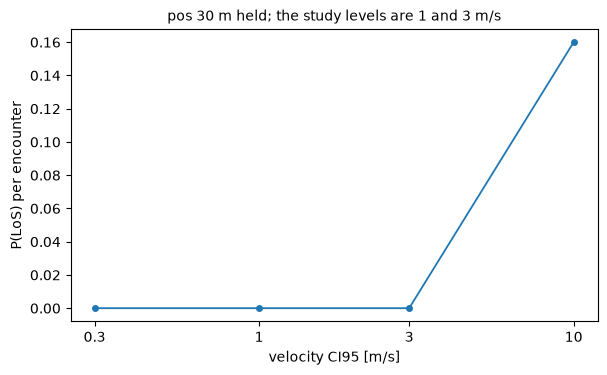

In [4]:
res_vel = run({'vel_ci95': Sweep([0.3, 1.0, 3.0, 10.0])})
df = res_vel.to_dataframe()
display(df.round(4))
plot_response(df, 'vel_ci95', 'velocity CI95 [m/s]', log_x=True,
              title='pos 30 m held; the study levels are 1 and 3 m/s')

## 4. Reception probability — `reception_prob`

Per-transmission Bernoulli on the broadcast channel (ADR 0002). A missed
broadcast leaves the receiver flying on a stale contact — latency plus
holdover — so the resolver manoeuvres against where the intruder *was*.

,reception_prob,n_encounters,n_los,p_los_run,detection_rate,median_min_sep,n_unsettled
0,0.2,200,2,0.010,1.0,127.5753,0
1,0.4,200,3,0.015,1.0,120.0161,0
2,0.6,200,1,0.005,1.0,113.7771,0
3,0.8,200,0,0.000,1.0,113.9731,0
4,1.0,200,0,0.000,1.0,119.2431,0


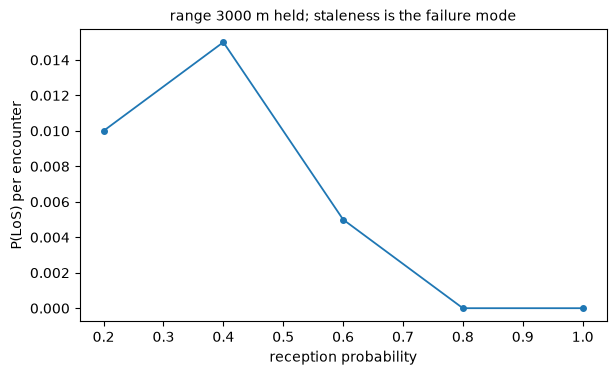

In [5]:
res_rx = run({'reception_prob': Sweep([0.2, 0.4, 0.6, 0.8, 1.0])})
df = res_rx.to_dataframe()
display(df.round(4))
plot_response(df, 'reception_prob', 'reception probability',
              title='range 3000 m held; staleness is the failure mode')

## 5. Surveillance range — `max_range_m`

A hard gate at transmit time: beyond it the counterpart has never been heard
and is simply not detectable (contacts start invalid — ADR 0002 D2). Short
ranges turn every encounter into a late-sight encounter: at 21 m/s closure a
200 m first sight is ~9 s before closest approach.

,max_range_m,n_encounters,n_los,p_los_run,detection_rate,median_min_sep,n_unsettled
0,200.0,200,45,0.225,1.0,70.4509,0
1,500.0,200,1,0.005,1.0,97.7234,0
2,1000.0,200,0,0.000,1.0,105.1573,0
3,3000.0,200,0,0.000,1.0,113.9731,0


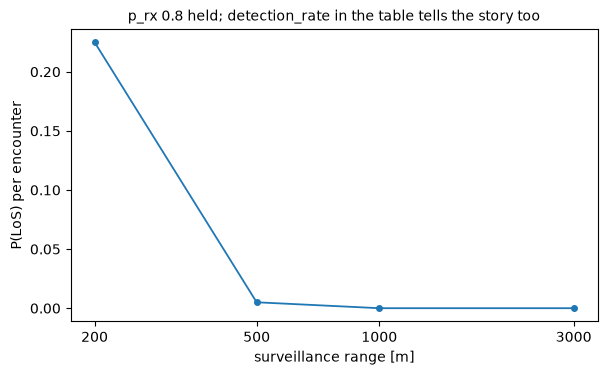

In [6]:
res_range = run({'max_range_m': Sweep([200.0, 500.0, 1000.0, 3000.0])})
df = res_range.to_dataframe()
display(df.round(4))
plot_response(df, 'max_range_m', 'surveillance range [m]', log_x=True,
              title='p_rx 0.8 held; detection_rate in the table tells the story too')

## 6. Aircraft type — `aircraft`

The categorical axis: a catalog label routed through the registry
(ADR 0005). `multirotor` is the M600 exactly as CDaRR ran it — turn-rate
limited at 15 deg/s, envelope up to 18 m/s; `fixedwing` is OpenCDaRR's small
fixed-wing UAV — bank-limited turns (44 deg) and a 12 m/s stall floor, so it
cannot resolve by slowing down. Two lone conditions would be a dull plot, so
this section also shows how axes cross: two `Sweep`s in one declaration make
the product, and each airframe gets its full position-uncertainty response.

,aircraft,pos_ci95,n_encounters,n_los,p_los_run,detection_rate,median_min_sep,n_unsettled
0,multirotor,3.0,200,0,0.000,1.0,109.9274,0
1,multirotor,10.0,200,1,0.005,1.0,110.9318,0
2,multirotor,30.0,200,0,0.000,1.0,113.9731,0
3,multirotor,92.6,200,9,0.045,1.0,140.8432,0
4,fixedwing,3.0,200,0,0.000,1.0,105.3192,0
5,fixedwing,10.0,200,0,0.000,1.0,115.1012,0
6,fixedwing,30.0,200,0,0.000,1.0,113.9398,0
7,fixedwing,92.6,200,8,0.040,1.0,148.9143,0


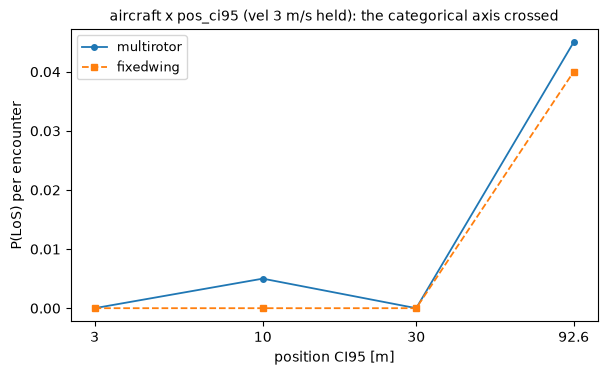

In [7]:
res_ac = run({'aircraft': Sweep(['multirotor', 'fixedwing']),
              'pos_ci95': Sweep([3.0, 10.0, 30.0, 92.6])})
df = res_ac.to_dataframe()
display(df.round(4))

fig, ax = plt.subplots(figsize=(6.8, 3.8))
for label, fmt in (('multirotor', '-o'), ('fixedwing', '--s')):
    part = df[df['aircraft'] == label]
    ax.plot(part['pos_ci95'], part['p_los_run'], fmt, ms=4, lw=1.3, label=label)
ax.set_xscale('log')
ax.set_xticks([3.0, 10.0, 30.0, 92.6], ['3', '10', '30', '92.6'])
ax.minorticks_off()
ax.set_xlabel('position CI95 [m]')
ax.set_ylabel('P(LoS) per encounter')
ax.set_title('aircraft x pos_ci95 (vel 3 m/s held): the categorical axis crossed', fontsize=10)
ax.legend(fontsize=9)
plt.show()

## 7. One MixedVarLSENew sample, at production budget

Everything above tabulates conditions; the level-set study instead calls a
**blackbox**: a batch of design points in, one `(log10 P(LoS), se)` per point
out (Jeffreys-corrected proportion, delta-method standard error — the
estimator from the `opencdarr_blackbox` notebook, verbatim). A point is a
plain dict keyed by the design-space names.

Here `n_encounters=100_000` **replaces the demo budget** — just as an
example of a production-scale sample: 200 encounters resolve ~1e-2, but the
study thresholds sit lower (log10 0.02 ≈ −1.7, production 1e-5), and 100k
encounters resolve probabilities down to ~1e-4 with usable error. Expect this
cell to run for several minutes (1 000 episodes, all cores).

In [8]:
import time
from cdarr.blackbox import make_blackbox

blackbox = make_blackbox(
    n_encounters=100_000,          # production budget (demo sections used 200)
    seed=7,
    base_config=Config(            # the study's fixed half; reception/range
        comm=CommConfig(latency_s=0.1, broadcast_jitter_s=0.1),  # come per point
    ),
    n_jobs=-1,                     # spend the worker budget inside the simulator
)

point = {
    'p_reception': 0.6,
    'max_range_m': 500.0,
    'kinematics': 'multirotor',
    'pos_ci95_m': 30.0,
    'vel_ci95_ms': 3.0,
}

t0 = time.perf_counter()
[(y, se)] = blackbox([point])      # a batch of one, per the mvlse contract
elapsed = time.perf_counter() - t0

print(f'log10 P(LoS) = {y:.4f}   (P(LoS) ~ {10**y:.2e})')
print(f'se           = {se:.4f} decades')
print(f'wall time    = {elapsed/60:.1f} min for 100,000 encounters')

log10 P(LoS) = -2.1161   (P(LoS) ~ 7.65e-03)
se           = 0.0156 decades
wall time    = 1.6 min for 100,000 encounters


On the MixedVarLSENew side this callable plugs straight into the study —
the only change from its OpenCDaRR notebook is the import:

```python
from mvlse import DesignSpace, Continuous, Nominal, Ordinal, run_lse

space = DesignSpace({
    'p_reception': Continuous(0.20, 1.00),
    'max_range_m': Continuous(200.0, 3000.0),
    'kinematics':  Nominal(['multirotor', 'fixedwing']),
    'pos_ci95_m':  Ordinal([3.0, 10.0, 30.0, 92.6]),
    'vel_ci95_ms': Ordinal([1.0, 3.0]),
})
result = run_lse(space, blackbox, threshold=np.log10(0.02),
                 store='bluesky_p_los.jsonl', seed=7)
```

## From here to the full study

These five axes are the MixedVarLSENew design space. The pieces compose:

- **Full factorial from one file** — `configs/mixedvarlse.yaml` declares the
  fixed half and a `sweep:` block over all five (plus `aircraft`); run it with
  `.venv/bin/python scripts/run_experiment.py configs/mixedvarlse.yaml --jobs -1`
  to get a tidy CSV and a provenance card.
- **Cross-products in Python** — put several `Sweep`s in one declaration and
  the conditions are their product, in declaration order.
- **As the LSE oracle** — `cdarr.blackbox.make_blackbox(n_encounters=300,
  seed=7, n_jobs=-1)` wraps exactly these runs into the
  `points -> [(log10 P(LoS), se)]` callable `mvlse.run_lse` consumes.

Validation behind all of this: `vault/correctness.md`.